# Customer Segmentation — Phase 1: EDA
Mall Customers Dataset

In [1]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5"})
 
GENDER_COLORS = {"Male": "#4C72B0", "Female": "#E07070"}

In [2]:
# Loading Data

df = pd.read_csv("Mall_Customers.csv")
 
# Standardise column names — Kaggle version uses spaces
df.columns = df.columns.str.strip()
df.rename(columns={
    "CustomerID"                    : "CustomerID",
    "Genre"                         : "Gender",
    "Gender"                        : "Gender",
    "Age"                           : "Age",
    "Annual Income (k$)"            : "AnnualIncome",
    "Spending Score (1-100)"        : "SpendingScore",
}, inplace=True)
 
# Keep only the columns we need
KEEP = ["CustomerID", "Gender", "Age", "AnnualIncome", "SpendingScore"]
df = df[[c for c in KEEP if c in df.columns]]
 
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names : {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes.to_string()}")
print(f"\nMissing values: {df.isnull().sum().sum()}  (should be 0)")
print(f"\nFirst 5 rows:")
print(df.head().to_string(index=False))
print(f"\nNumerical summary:")
print(df.describe().round(1).to_string())

DATASET OVERVIEW
Shape  : 200 rows × 5 columns

Column names : ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']

Data types:
CustomerID        int64
Gender           object
Age               int64
AnnualIncome      int64
SpendingScore     int64

Missing values: 0  (should be 0)

First 5 rows:
 CustomerID Gender  Age  AnnualIncome  SpendingScore
          1   Male   19            15             39
          2   Male   21            15             81
          3 Female   20            16              6
          4 Female   23            16             77
          5 Female   31            17             40

Numerical summary:
       CustomerID    Age  AnnualIncome  SpendingScore
count       200.0  200.0         200.0          200.0
mean        100.5   38.8          60.6           50.2
std          57.9   14.0          26.3           25.8
min           1.0   18.0          15.0            1.0
25%          50.8   28.8          41.5           34.8
50%         100.5   36.0    

GENDER SPLIT


Gender split:
  Female: 112  (56.0%)
  Male: 88  (44.0%)


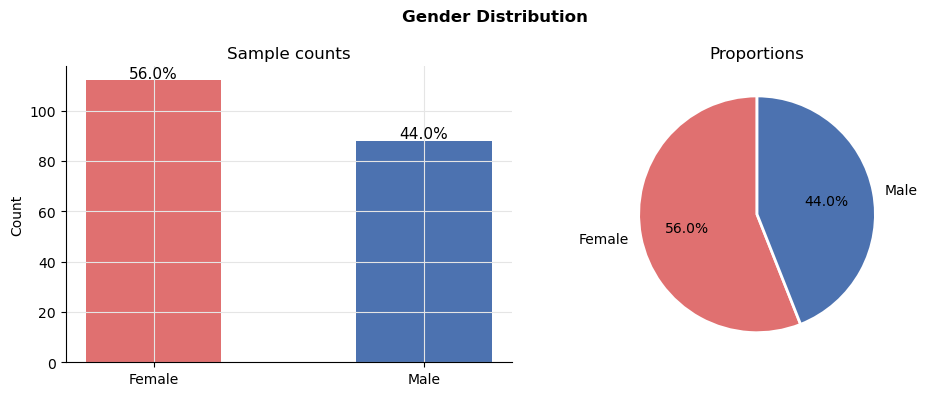

In [3]:
gender_counts = df["Gender"].value_counts()
gender_pcts   = df["Gender"].value_counts(normalize=True) * 100
 
print(f"\nGender split:")
for g in gender_counts.index:
    print(f"  {g}: {gender_counts[g]}  ({gender_pcts[g]:.1f}%)")
 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Gender Distribution", fontweight="bold")
 
# Bar chart
ax = axes[0]
bars = ax.bar(gender_counts.index, gender_counts.values,
              color=[GENDER_COLORS.get(g, "#888") for g in gender_counts.index],
              width=0.5)
ax.set_ylabel("Count")
ax.set_title("Sample counts")
for bar, pct in zip(bars, gender_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{pct:.1f}%", ha="center", fontsize=11)
 
# Pie chart
ax2 = axes[1]
ax2.pie(gender_counts.values,
        labels=gender_counts.index,
        colors=[GENDER_COLORS.get(g, "#888") for g in gender_counts.index],
        autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2})
ax2.set_title("Proportions")
ax2.grid(False)
 
plt.tight_layout()
plt.savefig("phase1_gender_split.png", dpi=150, bbox_inches="tight")
plt.show()
 

 NUMERIC FEATURE DISTRIBUTIONS

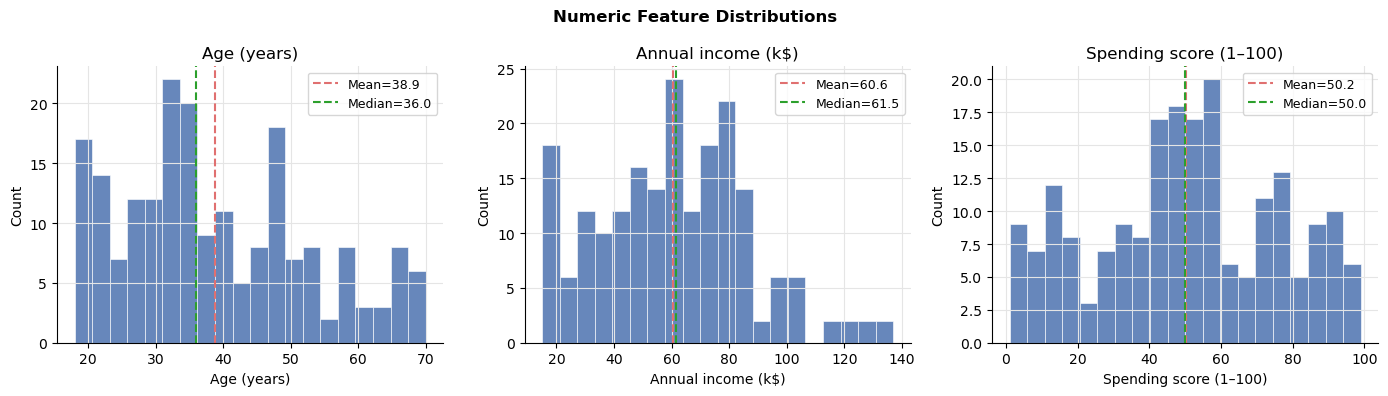


Numeric feature stats:
Feature              Mean   Median      Std    Min    Max    Skew
--------------------------------------------------------------
  Age (years)        38.9     36.0     14.0     18     70   0.486
  Annual income (k$)     60.6     61.5     26.3     15    137   0.322
  Spending score (1–100)     50.2     50.0     25.8      1     99  -0.047


In [4]:
NUMERIC = ["Age", "AnnualIncome", "SpendingScore"]
LABELS  = {
    "Age"          : "Age (years)",
    "AnnualIncome" : "Annual income (k$)",
    "SpendingScore": "Spending score (1–100)",
}
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Numeric Feature Distributions", fontweight="bold")
 
for ax, feat in zip(axes, NUMERIC):
    # Histogram
    ax.hist(df[feat], bins=20, color="#4C72B0",
            edgecolor="white", linewidth=0.5, alpha=0.85)
    # Mean and median lines
    mean = df[feat].mean()
    med  = df[feat].median()
    ax.axvline(mean, color="#E07070", linestyle="--",
               linewidth=1.5, label=f"Mean={mean:.1f}")
    ax.axvline(med,  color="#2ca02c", linestyle="--",
               linewidth=1.5, label=f"Median={med:.1f}")
    ax.set_title(LABELS[feat])
    ax.set_xlabel(LABELS[feat])
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("phase1_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\nNumeric feature stats:")
print(f"{'Feature':<16} {'Mean':>8} {'Median':>8} {'Std':>8} {'Min':>6} {'Max':>6} {'Skew':>7}")
print("-" * 62)
for feat in NUMERIC:
    print(f"  {LABELS[feat]:<14} "
          f"{df[feat].mean():>8.1f} "
          f"{df[feat].median():>8.1f} "
          f"{df[feat].std():>8.1f} "
          f"{df[feat].min():>6.0f} "
          f"{df[feat].max():>6.0f} "
          f"{df[feat].skew():>7.3f}")
 

DISTRIBUTIONS BY GENDER

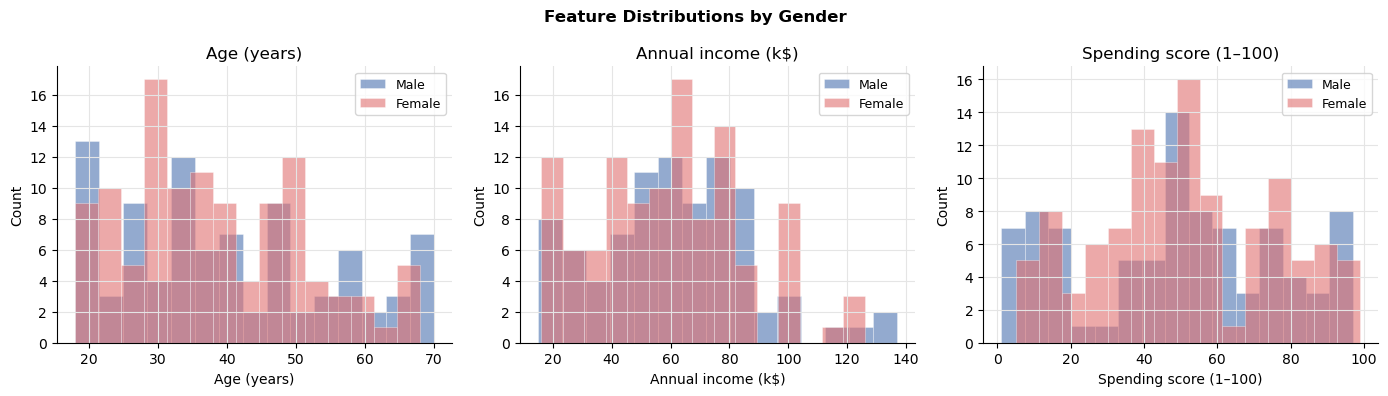

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Feature Distributions by Gender", fontweight="bold")
 
for ax, feat in zip(axes, NUMERIC):
    for gender, color in GENDER_COLORS.items():
        subset = df.loc[df["Gender"] == gender, feat]
        ax.hist(subset, bins=15, alpha=0.6, color=color,
                edgecolor="white", linewidth=0.4, label=gender)
    ax.set_title(LABELS[feat])
    ax.set_xlabel(LABELS[feat])
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("phase1_distributions_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()
 

 PAIRPLOT — COLOURED BY GENDER

c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


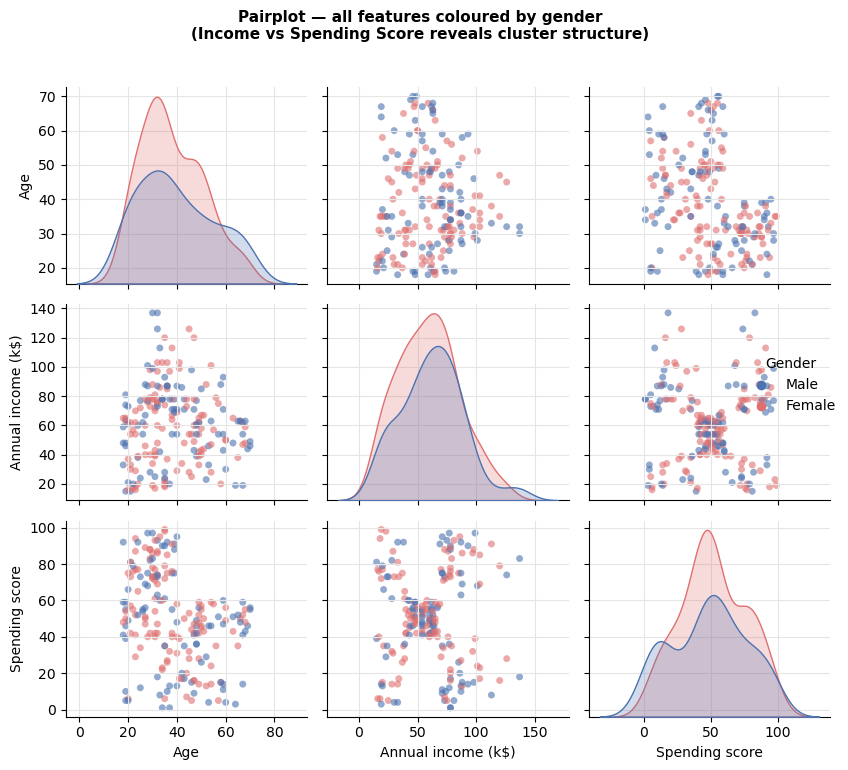


Key observation from pairplot:
  Income vs Spending Score scatter shows 5 distinct groupings —
  this is the primary feature space for K-Means in Phase 2.


In [6]:
pair_df = df[["Age", "AnnualIncome", "SpendingScore", "Gender"]].copy()
pair_df.columns = ["Age", "Annual income (k$)", "Spending score", "Gender"]
 
g = sns.pairplot(pair_df, hue="Gender",
                 palette=GENDER_COLORS,
                 plot_kws={"alpha": 0.6, "s": 25, "edgecolor": "none"},
                 diag_kind="kde",
                 corner=False)
g.figure.suptitle("Pairplot — all features coloured by gender\n"
                   "(Income vs Spending Score reveals cluster structure)",
                   y=1.02, fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("phase1_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\nKey observation from pairplot:")
print("  Income vs Spending Score scatter shows 5 distinct groupings —")
print("  this is the primary feature space for K-Means in Phase 2.")
 

CORRELATION HEATMAP

c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


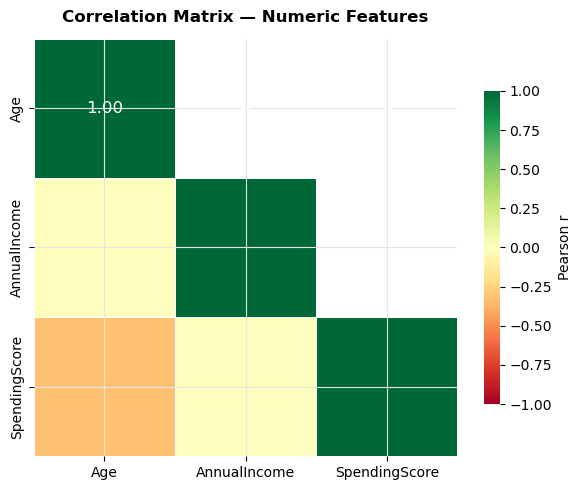


Correlations between numeric features:
                 Age  AnnualIncome  SpendingScore
Age            1.000        -0.012         -0.327
AnnualIncome  -0.012         1.000          0.010
SpendingScore -0.327         0.010          1.000

Weak correlations are expected — patterns come from
cluster structure, not from predicting a label.


In [7]:
corr = df[NUMERIC].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
 
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 12}, ax=ax,
            cbar_kws={"shrink": 0.75, "label": "Pearson r"})
ax.set_title("Correlation Matrix — Numeric Features", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("phase1_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\nCorrelations between numeric features:")
print(corr.round(3).to_string())
print("\nWeak correlations are expected — patterns come from")
print("cluster structure, not from predicting a label.")
 

Summary

In [8]:
print("\n" + "=" * 55)
print("PHASE 1 SUMMARY")
print("=" * 55)
print(f"  Rows            : {len(df)}")
print(f"  Features        : {len(NUMERIC)} numeric + 1 categorical (Gender)")
print(f"  Missing values  : 0")
print(f"  Gender split    : {gender_pcts.get('Female', 0):.1f}% Female / "
      f"{gender_pcts.get('Male', 0):.1f}% Male")
print(f"  Age range       : {df['Age'].min():.0f}–{df['Age'].max():.0f} yrs")
print(f"  Income range    : ${df['AnnualIncome'].min():.0f}k–${df['AnnualIncome'].max():.0f}k")
print(f"  Spending range  : {df['SpendingScore'].min():.0f}–{df['SpendingScore'].max():.0f}")
print(f"\n  Key insight: Income vs Spending Score scatter reveals")
print(f"  5 natural groupings — confirmed in Phase 2 by elbow + silhouette.")
 
print("\nSaved:")
print("  phase1_gender_split.png")
print("  phase1_distributions.png")
print("  phase1_distributions_by_gender.png")
print("  phase1_pairplot.png")
print("  phase1_correlation_heatmap.png")
print("\nNext: Phase 2 — K-Means, elbow method & silhouette scores")


PHASE 1 SUMMARY
  Rows            : 200
  Features        : 3 numeric + 1 categorical (Gender)
  Missing values  : 0
  Gender split    : 56.0% Female / 44.0% Male
  Age range       : 18–70 yrs
  Income range    : $15k–$137k
  Spending range  : 1–99

  Key insight: Income vs Spending Score scatter reveals
  5 natural groupings — confirmed in Phase 2 by elbow + silhouette.

Saved:
  phase1_gender_split.png
  phase1_distributions.png
  phase1_distributions_by_gender.png
  phase1_pairplot.png
  phase1_correlation_heatmap.png

Next: Phase 2 — K-Means, elbow method & silhouette scores
